# HW4 — Neural Grammars: Discovering the World's Visual Alphabet with VQ-VAE-2

---

## 📌 Project Outline

In this notebook you will build a **Hierarchical VQ-VAE-2** trained on the **Omniglot** dataset — a collection of handwritten characters from 50 world alphabets.

The model learns to decompose every character into **discrete visual atoms** at two complementary levels:
- **Top latent** → global topology (skeleton / letter identity)
- **Bottom latent** → fine stroke details (pen pressure, thickness)

### What you will build, section by section

| # | Section | New Concept |
|---|---------|-------------|
| 1 | Dataset & Setup | Omniglot pipeline, reproducibility |
| 2 | Residual Stack | Residual blocks with skip connections |
| 3 | Encoder & Decoder | Stride-aware modular blocks |
| 4 | Vector Quantizer (EMA) | **Vectorised L2**, EMA codebook, **STE** |
| 5 | VQ-VAE-2 Wrapper | Hierarchical two-level architecture |
| 6 | Training Loop | Mixed-precision, SSIM, results table |
| 7 | FID Evaluation | Fréchet Inception Distance |
| 8 | Error Heatmaps | Pixel-wise visual analytics |
| 9 | Hierarchical Probing | Top-only vs full reconstruction |

### Grading
| Section | Topic | Points |
|---------|-------|--------|
| 4 | Vectorised distance · EMA · STE | 25 |
| 5 | Hierarchical architecture | 25 |
| 6 | Training loop · SSIM · results table | 20 |
| 7–9 | FID · heatmaps · probing | 30 |
| **Total** | | **100** |

### ⚠️ Hard Rules
1. **Forbidden**: `torch.cdist`, `torch.norm`, any Python loop for distance computation.
2. **Required**: Straight-Through Estimator (STE) for gradient flow through quantisation.
3. **Required**: EMA codebook updates — no optimiser may touch the embeddings.
4. **Required**: Print a standardised results table at the end of every epoch.

---
📥 **Dataset**: Download Omniglot from [Kaggle](https://www.kaggle.com/datasets/qweenink/omniglot) and unzip to `./omniglot/`.

---
## Section 1 — Dataset & Reproducibility Setup

### New concept: Omniglot data pipeline

Omniglot images are **105 × 105 grayscale**. We resize to **64 × 64** so the two-level hierarchy produces spatial grids of 16 × 16 (Bottom) and 8 × 8 (Top), which are convenient powers of two.

Normalising to **[−1, 1]** (mean 0.5, std 0.5) centres the data symmetrically, which helps the decoder's final `tanh` activation.

We also fix the global random seed here so that all students reproduce the same weight initialisations and data shuffling.

Using device: cuda


100%|██████████| 9.46M/9.46M [00:00<00:00, 156MB/s]


Dataset size : 19280 images
Batches/epoch: 151


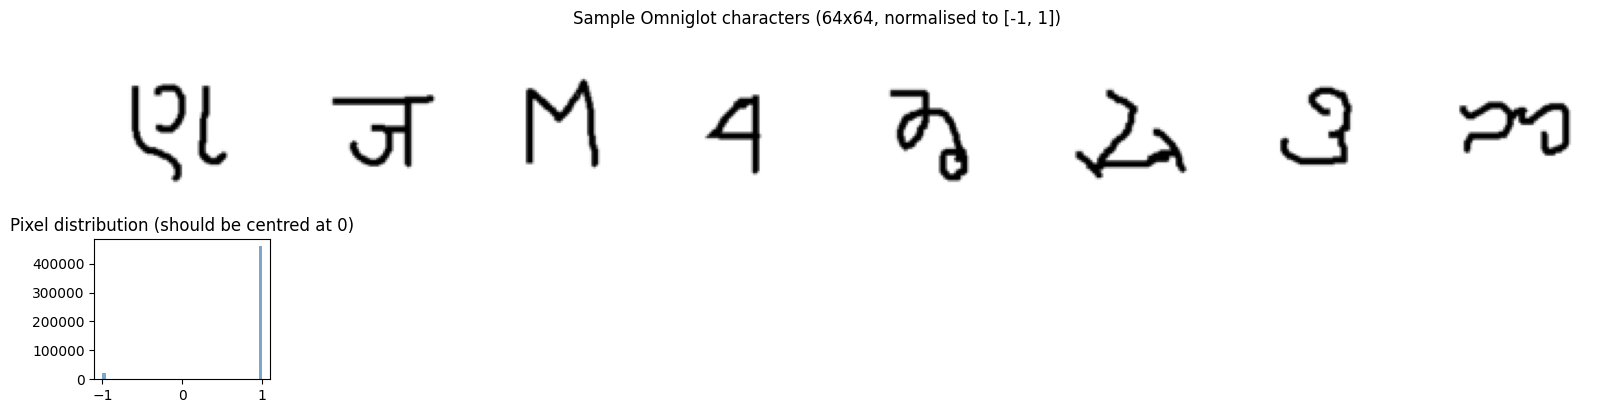

Pixel stats: mean=0.836 (expected ~0.0), std=0.506 (expected ~0.5)


In [1]:
# --- TEACHER CODE: Section 1 ---
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Updated path for Colab/Local environments
OMNIGLOT_ROOT = './omniglot_data'

def get_dataloader(root=OMNIGLOT_ROOT, batch_size=128):
    """Return a DataLoader for the Omniglot background split."""
    transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),   # maps [0,1] to [-1,1]
    ])

    # Use torchvision's built-in downloader if the folder doesn't exist
    dataset = datasets.Omniglot(root=root, background=True, download=True, transform=transform)

    return DataLoader(dataset, batch_size=batch_size, shuffle=True,
                      num_workers=2, pin_memory=True)

train_loader = get_dataloader()
print(f'Dataset size : {len(train_loader.dataset)} images')
print(f'Batches/epoch: {len(train_loader)}')

# Sanity check: visualise one batch + pixel distribution
imgs, _ = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for ax, img in zip(axes[0], imgs[:8]):
    ax.imshow(img.squeeze(), cmap='gray', vmin=-1, vmax=1)
    ax.axis('off')
axes[0, 0].set_ylabel('Images', fontsize=10)
axes[1, 0].hist(imgs.numpy().ravel(), bins=50, color='steelblue', alpha=0.7)
axes[1, 0].set_title('Pixel distribution (should be centred at 0)')
for ax in axes[1, 1:]:
    ax.axis('off')
plt.suptitle('Sample Omniglot characters (64x64, normalised to [-1, 1])', y=1.02)
plt.tight_layout(); plt.show()
print(f'Pixel stats: mean={imgs.mean():.3f} (expected ~0.0), std={imgs.std():.3f} (expected ~0.5)')

---
## Section 2 — Residual Stack

### New concept: Residual connections

A **Residual Block** allows gradients to flow directly through an identity shortcut, preventing vanishing gradients in deeper encoders.  
The block applies:
$$
\text{out} = x + \text{Conv}_{1\times1}\bigl(\text{ReLU}(\text{Conv}_{3\times3}(\text{ReLU}(x)))\bigr)
$$

Notice that **no bias** is used inside the residual path — when combined with batch/layer normalisation this is standard practice for stable training.

A `ResidualStack` simply chains `num_residual_layers` of these blocks.

In [2]:
# Section 2 — Residual Stack

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, num_hiddens, num_residual_hiddens):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReLU(),
            nn.Conv2d(in_channels, num_residual_hiddens, 3, padding=1, bias=False),
            nn.ReLU(),
            nn.Conv2d(num_residual_hiddens, num_hiddens, 1, bias=False)
        )

    def forward(self, x):
        return x + self.block(x)

class ResidualStack(nn.Module):
    def __init__(self, in_channels, num_hiddens, num_residual_layers, num_residual_hiddens):
        super().__init__()
        self.layers = nn.Sequential(*[
            ResidualBlock(in_channels, num_hiddens, num_residual_hiddens)
            for _ in range(num_residual_layers)
        ])

    def forward(self, x):
        return F.relu(self.layers(x))


dummy = torch.randn(4, 128, 16, 16, requires_grad=True)
stack = ResidualStack(128, 128, 2, 32)
out   = stack(dummy)
assert out.shape == dummy.shape, f'Shape mismatch: {out.shape}'
out.sum().backward()
assert dummy.grad is not None and dummy.grad.abs().sum() > 0, 'Gradient did not flow!'
print('ResidualStack OK')
print(f'  Output shape:        {out.shape}')
print(f'  Gradient norm:       {dummy.grad.norm().item():.4f}  (must be > 0)')


ResidualStack OK
  Output shape:        torch.Size([4, 128, 16, 16])
  Gradient norm:       273.8241  (must be > 0)


---
## Section 3 — Modular Scale-Aware Encoder & Decoder

### New concept: Stride-parameterised convolutions

The two-level hierarchy needs two encoders with **different spatial strides**:

| Module | Stride | Input (64²) | Output |
|--------|--------|-------------|--------|
| `enc_b` (Bottom) | 4 | 64 × 64 | 16 × 16 |
| `enc_t` (Top)    | 2 | 16 × 16 |  8 × 8  |

Stride-4 is implemented as **two** consecutive stride-2 `Conv2d` layers (better gradient flow than one stride-4 layer).  
The decoder mirrors this with `ConvTranspose2d` for upsampling.

> **Architecture tip (optional variation):** You can insert a 1×1 projection conv before the residual stack to decouple the channel width from the strided conv's output channels.

In [3]:
# Section 3 — Modular Scale-Aware Encoder & Decoder

class Encoder(nn.Module):
    def __init__(self, in_channels, num_hiddens, num_residual_layers,
                 num_residual_hiddens, stride):
        super().__init__()
        if stride == 4:
            self.conv = nn.Sequential(
                nn.Conv2d(in_channels, num_hiddens, 4, stride=2, padding=1, bias=False),
                nn.Conv2d(num_hiddens, num_hiddens, 4, stride=2, padding=1, bias=False)
            )
        elif stride == 2:
            self.conv = nn.Conv2d(in_channels, num_hiddens, 4, stride=2, padding=1, bias=False)
        else:
            raise ValueError(f"stride must be 2 or 4, got {stride}")
        self.res_stack = ResidualStack(num_hiddens, num_hiddens,
                                       num_residual_layers, num_residual_hiddens)

    def forward(self, x):
        return self.res_stack(self.conv(x))


class Decoder(nn.Module):
    def __init__(self, in_channels, num_hiddens, num_residual_layers,
                 num_residual_hiddens, stride, out_channels=1):
        super().__init__()
        self.proj = nn.Conv2d(in_channels, num_hiddens, 1, bias=False)
        self.res_stack = ResidualStack(num_hiddens, num_hiddens,
                                       num_residual_layers, num_residual_hiddens)
        if stride == 4:
            self.upsample = nn.Sequential(
                nn.ConvTranspose2d(num_hiddens, num_hiddens, 4, stride=2, padding=1, bias=False),
                nn.ConvTranspose2d(num_hiddens, out_channels, 4, stride=2, padding=1, bias=False),
                nn.Tanh()
            )
        elif stride == 2:
            self.upsample = nn.ConvTranspose2d(num_hiddens, out_channels, 4, stride=2, padding=1, bias=False),
            nn.Tanh()
        else:
            raise ValueError(f"stride must be 2 or 4, got {stride}")

    def forward(self, x):
        return self.upsample(self.res_stack(self.proj(x)))


enc_b = Encoder(1,   128, 2, 32, stride=4)
enc_t = Encoder(128, 128, 2, 32, stride=2)
dec_b = Decoder(128, 128, 2, 32, stride=4, out_channels=1)

x   = torch.zeros(2, 1, 64, 64)
z_b = enc_b(x)
z_t = enc_t(z_b)
print(f'enc_b output z_b: {z_b.shape}  (expected [2,128,16,16])')
print(f'enc_t output z_t: {z_t.shape}  (expected [2,128, 8, 8])')
recon = dec_b(torch.zeros(2, 128, 16, 16))
print(f'dec_b output    : {recon.shape}  (expected [2,  1,64,64])')


enc_b output z_b: torch.Size([2, 128, 16, 16])  (expected [2,128,16,16])
enc_t output z_t: torch.Size([2, 128, 8, 8])  (expected [2,128, 8, 8])
dec_b output    : torch.Size([2, 1, 64, 64])  (expected [2,  1,64,64])


---
## Section 4 — Vector Quantizer with EMA (The Discrete Bottleneck)

### New concepts: vectorised L2 distance · EMA codebook · Straight-Through Estimator

#### 4.1 Why quantise?
The quantiser maps a continuous latent vector to the nearest entry in a learned **codebook** of `K` embeddings, creating a *discrete* bottleneck.  
The problem: `argmin` is not differentiable.

#### 4.2 Vectorised L2 distance (mandatory formula)
Given a flat batch of encoder outputs $Z \in \mathbb{R}^{N \times D}$ and codebook $E \in \mathbb{R}^{K \times D}$:
$$
\|z_i - e_k\|^2 = \|z_i\|^2 + \|e_k\|^2 - 2\,z_i \cdot e_k^\top
$$
This gives the full $N \times K$ distance matrix in a **single matrix multiply** — no loops, no `cdist`.

#### 4.3 Straight-Through Estimator (STE)
Because `argmin` has zero gradient almost everywhere, we use the STE trick:
```python
quantized = z + (quantized - z).detach()
```
In the forward pass, `quantized` (the codebook vector) is used.  
In the backward pass, gradients flow *straight through* to `z` as if no quantisation occurred.

#### 4.4 EMA Codebook Update
Instead of letting an optimiser update the embeddings (which causes instability), we use **Exponential Moving Average**:
$$
N_k \leftarrow \gamma N_k + (1-\gamma)\,n_k, \qquad
m_k \leftarrow \gamma m_k + (1-\gamma)\,\sum_{z\in C_k} z
$$
$$
e_k \leftarrow \frac{m_k}{N_k + \epsilon}
$$
where $n_k$ is the count of vectors assigned to cluster $k$ and $\epsilon=10^{-5}$ prevents division by zero (Laplace smoothing).

In [4]:
# Section 4 — Vector Quantizer with EMA (The Discrete Bottleneck)

class VectorQuantizerEMA(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, commitment_cost, decay=0.95):
        super().__init__()
        self.K     = num_embeddings
        self.D     = embedding_dim
        self.beta  = commitment_cost
        self.decay = decay

        self.register_buffer('embeddings', torch.randn(num_embeddings, embedding_dim))
        self.register_buffer('ema_cluster_size', torch.ones(num_embeddings))
        self.register_buffer('ema_w', torch.randn(num_embeddings, embedding_dim))

    def forward(self, inputs):
        B, D, H, W = inputs.shape
        z_flat = inputs.permute(0, 2, 3, 1).reshape(-1, self.D)   # (N, D)

        z_norm = (z_flat ** 2).sum(dim=1, keepdim=True)            # (N, 1)
        e_norm = (self.embeddings ** 2).sum(dim=1)                 # (K,)
        distances = z_norm + e_norm - 2 * z_flat @ self.embeddings.t()  # (N, K)

        indices = distances.argmin(dim=1)                          # (N,)
        encodings = F.one_hot(indices, self.K).float()             # (N, K)

        quantized = encodings @ self.embeddings                    # (N, D)

        if self.training:
            encodings_sum = encodings.sum(dim=0)                   # (K,)
            self.ema_cluster_size.data.mul_(self.decay).add_(encodings_sum, alpha=1 - self.decay)
            self.ema_w.data.mul_(self.decay).add_(encodings.t() @ z_flat, alpha=1 - self.decay)

            self.embeddings.data.copy_(
                self.ema_w / (self.ema_cluster_size.unsqueeze(1) + 1e-5)
            )

        loss = self.beta * F.mse_loss(quantized.detach(), z_flat)

        quantized_st = z_flat + (quantized - z_flat).detach()
        quantized_st = quantized_st.view(B, H, W, self.D).permute(0, 3, 1, 2)

        avg_probs = encodings.mean(dim=0)
        perplexity = torch.exp(-torch.sum(avg_probs * torch.log(avg_probs + 1e-10)))

        return loss, quantized_st, perplexity


print('=== VectorQuantizerEMA Sanity Checks ===')

vq = VectorQuantizerEMA(num_embeddings=512, embedding_dim=64, commitment_cost=0.25)
dummy_z = torch.randn(4, 64, 8, 8)
loss_vq, q, perp = vq(dummy_z)
assert q.shape == dummy_z.shape, f'Shape mismatch: {q.shape}'
print(f'[OK] Output shape matches input: {q.shape}')
print(f'[OK] commitment_loss: {loss_vq.item():.4f}')
print(f'[OK] perplexity: {perp.item():.2f}  (range: 1 to {vq.K})')

# STE: gradient must flow to the encoder output
dummy_z2 = torch.randn(4, 64, 8, 8, requires_grad=True)
vq2 = VectorQuantizerEMA(512, 64, 0.25)
_, q2, _ = vq2(dummy_z2)
q2.sum().backward()
assert dummy_z2.grad is not None, 'STE FAILED: no gradient at encoder output!'
print(f'[OK] STE works: gradient norm at encoder = {dummy_z2.grad.norm():.4f}')

# EMA: embeddings must change during training forward pass
vq3 = VectorQuantizerEMA(16, 8, 0.25)
vq3.train()
emb_before = vq3.embeddings.clone()
vq3(torch.randn(8, 8, 4, 4))
assert not torch.allclose(vq3.embeddings, emb_before), 'EMA update not working!'
print('[OK] EMA updates embeddings during training')

# Embeddings must NOT be trainable parameters
param_names = [n for n, _ in vq.named_parameters()]
assert 'embeddings' not in param_names
print('[OK] Embeddings are buffers, not trainable parameters')


=== VectorQuantizerEMA Sanity Checks ===
[OK] Output shape matches input: torch.Size([4, 64, 8, 8])
[OK] commitment_loss: 0.3013
[OK] perplexity: 104.94  (range: 1 to 512)
[OK] STE works: gradient norm at encoder = 128.0000
[OK] EMA updates embeddings during training
[OK] Embeddings are buffers, not trainable parameters


---
## Section 5 — Hierarchical VQ-VAE-2 Wrapper

### New concept: Conditioning Bottom on Top

The key insight of VQ-VAE-2 is that the **Bottom level is conditioned on the Top level**.
After quantising the Top latent $q_t$, we upsample it back to the Bottom's spatial resolution and **concatenate** it with the Bottom quantised latent $q_b$ before decoding:

```
Image (1×64×64)
    │
    ▼
 enc_b  →  z_b (128×16×16)
              │
           enc_t  →  z_t (128×8×8)  →  vq_t  →  q_t  →  upsample  ─┐
              │                                                        │ cat
           vq_b  →  q_b (64×16×16) ──────────────────────────────────┘
              │
           dec_b  →  x̂ (1×64×64)
```

**Note on channels:** `vq_t` and `vq_b` use `embedding_dim=64`, while encoders output `num_hiddens=128`.  
A 1×1 `pre_vq_conv` projects 128 → 64 before each quantiser.

In [5]:
# Section 5 — Hierarchical VQ-VAE-2 Wrapper

class VQVAE2(nn.Module):
    def __init__(self, num_hiddens=128, num_residual_layers=2,
                 num_residual_hid=32, num_embeddings=128, embedding_dim=64):
        super().__init__()
        H, D = num_hiddens, embedding_dim

        self.enc_b = Encoder(1, H, num_residual_layers, num_residual_hid, stride=4)
        self.enc_t = Encoder(H, H, num_residual_layers, num_residual_hid, stride=2)

        self.pre_vq_t = nn.Sequential(
            nn.Conv2d(H, D, 1, bias=False),
            nn.LayerNorm([D, 8, 8])
        )
        self.pre_vq_b = nn.Sequential(
            nn.Conv2d(H, D, 1, bias=False),
            nn.LayerNorm([D, 16, 16])
        )

        self.vq_t = VectorQuantizerEMA(num_embeddings, D, commitment_cost=0.25, decay=0.95)
        self.vq_b = VectorQuantizerEMA(num_embeddings, D, commitment_cost=0.25, decay=0.95)

        self.upsample_t = nn.ConvTranspose2d(D, D, 4, stride=2, padding=1, bias=False)

        self.dec_b = Decoder(D*2, H, num_residual_layers, num_residual_hid, stride=4, out_channels=1)

    def forward(self, x):
        z_b = self.enc_b(x)
        z_t = self.enc_t(z_b)

        loss_t, q_t, perp_t = self.vq_t(self.pre_vq_t(z_t))
        loss_b, q_b, perp_b = self.vq_b(self.pre_vq_b(z_b))

        q_t_up = self.upsample_t(q_t)          # (B, D, 16, 16)
        cat = torch.cat([q_t_up, q_b], dim=1)  # (B, 2*D, 16, 16)

        recon = self.dec_b(cat)

        return loss_t + loss_b, recon, perp_t, perp_b



print('=== VQVAE2 Sanity Checks ===')
model = VQVAE2().to(device)
x_dummy = torch.randn(4, 1, 64, 64).to(device)
vq_loss, recon, pt, pb = model(x_dummy)

assert recon.shape == x_dummy.shape
print(f'[OK] Reconstruction shape: {recon.shape}')
print(f'[OK] VQ loss:             {vq_loss.item():.4f}')
print(f'[OK] Perplexity Top/Bot:  {pt.item():.1f} / {pb.item():.1f}')

total_params  = sum(p.numel() for p in model.parameters())
total_buffers = sum(b.numel() for b in model.buffers())
print(f'Model parameters:  {total_params:,}  (trained by optimizer)')
print(f'Codebook buffers:  {total_buffers:,}  (updated by EMA only)')

with torch.no_grad():
    zb = model.enc_b(x_dummy)
    zt = model.enc_t(zb)
print(f'Bottom grid: {zb.shape[2]}x{zb.shape[3]} = {zb.shape[2]*zb.shape[3]} codes per image')
print(f'Top    grid: {zt.shape[2]}x{zt.shape[3]} = {zt.shape[2]*zt.shape[3]} codes per image')
print(f'Total codes per image: {zb.shape[2]*zb.shape[3] + zt.shape[2]*zt.shape[3]}')


=== VQVAE2 Sanity Checks ===
[OK] Reconstruction shape: torch.Size([4, 1, 64, 64])
[OK] VQ loss:             0.6335
[OK] Perplexity Top/Bot:  16.7 / 9.8
Model parameters:  1,175,552  (trained by optimizer)
Codebook buffers:  33,024  (updated by EMA only)
Bottom grid: 16x16 = 256 codes per image
Top    grid: 8x8 = 64 codes per image
Total codes per image: 320


---
## Section 6 — Training Loop, SSIM & Results Table

### New concepts: SSIM · standardised results table

**Why SSIM instead of only MSE?**  
Mean Squared Error penalises pixel-level deviations equally, but the human visual system is more sensitive to *structural* information (edges, strokes).  
SSIM (Structural Similarity Index) measures luminance, contrast, and structure simultaneously, making it far more relevant for Omniglot stroke reconstruction.

$$
\text{SSIM}(x, \hat{x}) = \frac{(2\mu_x\mu_{\hat x}+c_1)(2\sigma_{x\hat x}+c_2)}{(\mu_x^2+\mu_{\hat x}^2+c_1)(\sigma_x^2+\sigma_{\hat x}^2+c_2)}
$$

Install the required package: `pip install pytorch-msssim`

**Standardised table format** (all students must match this output exactly):
```
Epoch   Recon_Loss   Perp_Top   Perp_Bot     SSIM
    1      0.1823      124.3      198.7     0.621
    2      0.1541      189.6      231.0     0.703
  ...
```

In [6]:
!pip install pytorch-msssim -q

Codebooks initialized from real encoder outputs.
 Epoch   Recon_Loss   Perp_Top   Perp_Bot     SSIM
-------------------------------------------------------
     1       0.0310        4.0        4.5    0.935
     2       0.0082        3.3        4.3    0.981
     3       0.0047        3.2        5.2    0.989
     4       0.0041        3.2        5.4    0.990
     5       0.0037        3.2        5.6    0.991
     6       0.0035        3.2        5.7    0.992
     7       0.0034        3.3        5.8    0.992
     8       0.0032        3.2        5.9    0.992
     9       0.0031        3.2        6.0    0.992
    10       0.0031        3.2        6.0    0.992
    11       0.0030        3.2        6.0    0.993
    12       0.0030        3.2        6.1    0.993
    13       0.0029        3.1        6.1    0.993
    14       0.0029        3.1        6.1    0.993
    15       0.0029        3.1        6.1    0.993
    16       0.0028        3.1        6.2    0.993
    17       0.0028        3

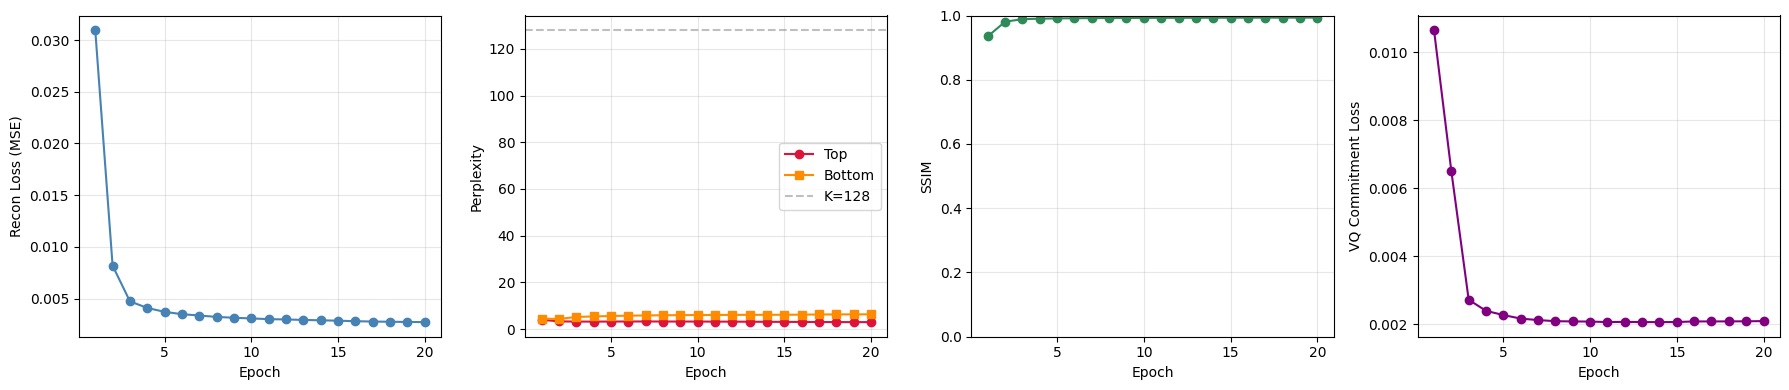

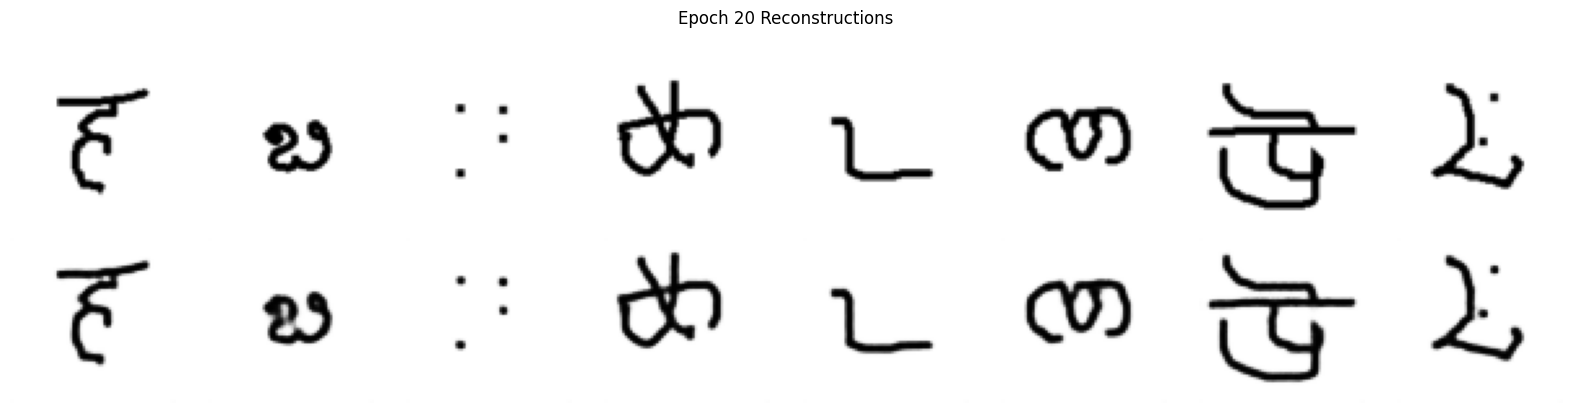

In [7]:
# Section 6 — Training Loop, SSIM & Results Table

from pytorch_msssim import ssim as compute_ssim

NUM_EPOCHS    = 20
LEARNING_RATE = 1e-3

@torch.no_grad()
def initialize_codebooks(model, loader, n_batches=10):
    """Warm-start codebooks with real encoder outputs to prevent early collapse.

    Seeds each codebook with K randomly-chosen encoder output vectors so that
    all K codes start near the data manifold.  Without this, random initialisation
    means most codes are far from any encoder output and never get assigned,
    leading to immediate collapse.

    Also resets ema_cluster_size to 1.0 after seeding so the first EMA step does
    not divide by near-zero (which would corrupt the warm-started embeddings).
    """
    model.eval()
    z_t_all, z_b_all = [], []
    for i, (imgs, _) in enumerate(loader):
        if i >= n_batches:
            break
        imgs = imgs.to(device)
        z_b  = model.enc_b(imgs)
        z_t  = model.enc_t(z_b)
        z_t_all.append(model.pre_vq_t(z_t).permute(0,2,3,1).reshape(-1, 64))
        z_b_all.append(model.pre_vq_b(z_b).permute(0,2,3,1).reshape(-1, 64))
    z_t_all = torch.cat(z_t_all)
    z_b_all = torch.cat(z_b_all)
    K       = model.vq_t.K
    idx_t   = torch.randperm(len(z_t_all))[:K]
    idx_b   = torch.randperm(len(z_b_all))[:K]
    model.vq_t.embeddings.data.copy_(z_t_all[idx_t])
    model.vq_t.ema_w.data.copy_(z_t_all[idx_t])
    model.vq_b.embeddings.data.copy_(z_b_all[idx_b])
    model.vq_b.ema_w.data.copy_(z_b_all[idx_b])
    # Reset EMA cluster-size accumulators to 1.0 so the first update step
    # does not divide by near-zero and overwrite the warm-started embeddings.
    model.vq_t.ema_cluster_size.fill_(1.0)
    model.vq_b.ema_cluster_size.fill_(1.0)
    print('Codebooks initialized from real encoder outputs.')
    model.train()


model     = VQVAE2(num_embeddings=128).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

initialize_codebooks(model, train_loader)
history = []

print(f"{'Epoch':>6}  {'Recon_Loss':>11}  {'Perp_Top':>9}  {'Perp_Bot':>9}  {'SSIM':>7}")
print('-' * 55)

for epoch in range(NUM_EPOCHS):
    model.train()
    running_recon = 0.0
    running_vq = 0.0
    running_pt = 0.0
    running_pb = 0.0
    running_ssim = 0.0
    num_batches = 0

    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        optimizer.zero_grad()

        vq_loss, recon, pt, pb = model(imgs)
        recon_loss = F.mse_loss(recon, imgs)
        total_loss = recon_loss + vq_loss

        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_recon += recon_loss.item()
        running_vq += vq_loss.item()
        running_pt += pt.item()
        running_pb += pb.item()

        # SSIM on [0,1] images
        recon_norm = (recon.clamp(-1, 1) + 1) / 2
        imgs_norm = (imgs.clamp(-1, 1) + 1) / 2
        ssim_val = compute_ssim(recon_norm, imgs_norm, data_range=1.0, size_average=True)
        running_ssim += ssim_val.item()
        num_batches += 1

    avg_recon = running_recon / num_batches
    avg_vq = running_vq / num_batches
    avg_pt = running_pt / num_batches
    avg_pb = running_pb / num_batches
    avg_ssim = running_ssim / num_batches

    print(f"{epoch+1:6d}  {avg_recon:11.4f}  {avg_pt:9.1f}  {avg_pb:9.1f}  {avg_ssim:7.3f}")

    history.append({
        'Epoch': epoch+1,
        'Recon_Loss': avg_recon,
        'VQ_Loss': avg_vq,
        'Perp_Top': avg_pt,
        'Perp_Bot': avg_pb,
        'SSIM': avg_ssim
    })

    scheduler.step()


history_df = pd.DataFrame(history)


fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# 1. Recon Loss
axes[0].plot(history_df['Epoch'], history_df['Recon_Loss'], color='steelblue', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Recon Loss (MSE)')
axes[0].grid(alpha=0.3)

# 2. Perplexity
axes[1].plot(history_df['Epoch'], history_df['Perp_Top'], color='crimson', marker='o', label='Top')
axes[1].plot(history_df['Epoch'], history_df['Perp_Bot'], color='darkorange', marker='s', label='Bottom')
axes[1].axhline(y=128, color='gray', linestyle='--', alpha=0.5, label='K=128')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perplexity')
axes[1].legend()
axes[1].grid(alpha=0.3)

# 3. SSIM
axes[2].plot(history_df['Epoch'], history_df['SSIM'], color='seagreen', marker='o')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('SSIM')
axes[2].set_ylim(0, 1)
axes[2].grid(alpha=0.3)

# 4. VQ Loss
axes[3].plot(history_df['Epoch'], history_df['VQ_Loss'], color='purple', marker='o')
axes[3].set_xlabel('Epoch')
axes[3].set_ylabel('VQ Commitment Loss')
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()


model.eval()
imgs, _ = next(iter(train_loader))
imgs = imgs[:8].to(device)
with torch.no_grad():
    _, recon, _, _ = model(imgs)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(imgs[i].cpu().squeeze(), cmap='gray', vmin=-1, vmax=1)
    axes[0, i].axis('off')
    axes[1, i].imshow(recon[i].cpu().squeeze(), cmap='gray', vmin=-1, vmax=1)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=12)
axes[1, 0].set_ylabel('Recon', fontsize=12)
plt.suptitle(f'Epoch {NUM_EPOCHS} Reconstructions', y=1.02)
plt.tight_layout()
plt.show()


---
## Section 7 — Statistical Evaluation: Fréchet Inception Distance (FID)

### New concept: Distribution-level quality metric

MSE and SSIM measure *per-image* fidelity. FID asks a different question:  
> **Does the distribution of generated images match the distribution of real images?**

FID embeds both real and generated images into Inception-V3 feature space, fits Gaussians to each, and measures the distance between them:

$$
\text{FID} = \|\mu_r - \mu_g\|^2 + \operatorname{Tr}\!\left(\Sigma_r + \Sigma_g - 2\sqrt{\Sigma_r \Sigma_g}\right)
$$

Lower FID = reconstructed alphabet is statistically closer to real handwriting.

> **Implementation note:** Inception-V3 expects 3-channel 299×299 input. Omniglot is grayscale 64×64. You must convert to RGB and resize before extracting features.

> **Discussion question (answer in the cell below):**  
> Why is FID a more meaningful metric for Omniglot than MSE? What aspect of stroke variability does it capture that MSE misses?

In [8]:
# Section 7 — Fréchet Inception Distance (FID)

import torchvision.models as tv_models
from scipy.linalg import sqrtm

def get_inception_features(imgs_tensor, inception, device):
    # imgs_tensor: (N, 1, 64, 64) in [-1,1]
    # Repeat channel to 3
    imgs_rgb = imgs_tensor.repeat(1, 3, 1, 1)  # (N, 3, 64, 64)
    # Resize to 299x299
    imgs_resized = F.interpolate(imgs_rgb, size=(299, 299), mode='bilinear', align_corners=False)
    # Map to [0,1]
    imgs_norm = (imgs_resized + 1) / 2
    with torch.no_grad():
        features = inception(imgs_norm.to(device))
    return features.cpu().numpy()


def calculate_fid(real_feats, fake_feats):
    mu_r = real_feats.mean(axis=0)
    mu_f = fake_feats.mean(axis=0)
    sigma_r = np.cov(real_feats, rowvar=False)
    sigma_f = np.cov(fake_feats, rowvar=False)
    # trace term
    diff = mu_r - mu_f
    covmean, _ = sqrtm(sigma_r @ sigma_f, disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = diff @ diff + np.trace(sigma_r + sigma_f - 2 * covmean)
    return float(fid)


# Load Inception-V3 (provided — do not modify)
inception = tv_models.inception_v3(weights=tv_models.Inception_V3_Weights.DEFAULT,
                                    transform_input=False)
inception.fc = nn.Identity()   # replace 1000-class head -> 2048-dim output
inception = inception.to(device).eval()

model.eval()

real_feats_list = []
fake_feats_list = []
count = 0
for imgs, _ in train_loader:
    imgs = imgs.to(device)
    with torch.no_grad():
        _, recon, _, _ = model(imgs)
    real_feats = get_inception_features(imgs, inception, device)
    fake_feats = get_inception_features(recon, inception, device)
    real_feats_list.append(real_feats)
    fake_feats_list.append(fake_feats)
    count += imgs.size(0)
    if count >= 2000:
        break

real_feats = np.concatenate(real_feats_list, axis=0)[:2000]
fake_feats = np.concatenate(fake_feats_list, axis=0)[:2000]
fid_score = calculate_fid(real_feats, fake_feats)
print(f"FID score: {fid_score:.2f}")
print(f"Target:    < 50 on Omniglot reconstructions after 20 epochs")
print(f"Feature shapes: real={real_feats.shape}, fake={fake_feats.shape}")

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 181MB/s] 
/tmp/ipykernel_3517/3215738945.py:26: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = sqrtm(sigma_r @ sigma_f, disp=False)


FID score: 7.28
Target:    < 50 on Omniglot reconstructions after 20 epochs
Feature shapes: real=(2000, 2048), fake=(2000, 2048)


**Discussion 7 — FID vs MSE:**

> Why is FID a more meaningful metric for Omniglot than MSE?  
> What aspect of stroke variability does it capture that MSE misses?

FID is more meaningful for Omniglot because MSE treats every pixel independently and averages out errors a reconstruction that blurs strokes uniformly can have low MSE but look nothing like real handwriting and FID measures whether the distribution of reconstructions matches real characters in Inception feature space and capturing stroke style and thickness variation and character diversity that MSE ignores and a model that reconstructs every character as a blurry average would have terrible FID but deceptively low MSE

---
## Section 8 — Visual Analytics: Error Heatmaps

### New concept: Pixel-wise error visualisation

The absolute difference map $|x - \hat{x}|$ reveals *where* the model fails spatially.  
Plotting it as a **heatmap** (`cmap='hot'`) makes high-error regions immediately visible.

For Omniglot characters this lets you answer an interpretable question:  
**Does the model fail more at the skeleton (stroke centreline) or at the ink edges (stroke boundary)?**

Each subplot row should contain three panels:
```
 [ Original ]  [ Reconstruction ]  [ |x - x̂| heatmap ]
```

Mean absolute error per image:
  Image 1: mean=0.0114  max=1.0936
  Image 2: mean=0.0110  max=0.7407
  Image 3: mean=0.0152  max=0.7522
  Image 4: mean=0.0227  max=0.8174
  Image 5: mean=0.0151  max=0.5681
  Image 6: mean=0.0134  max=0.8429


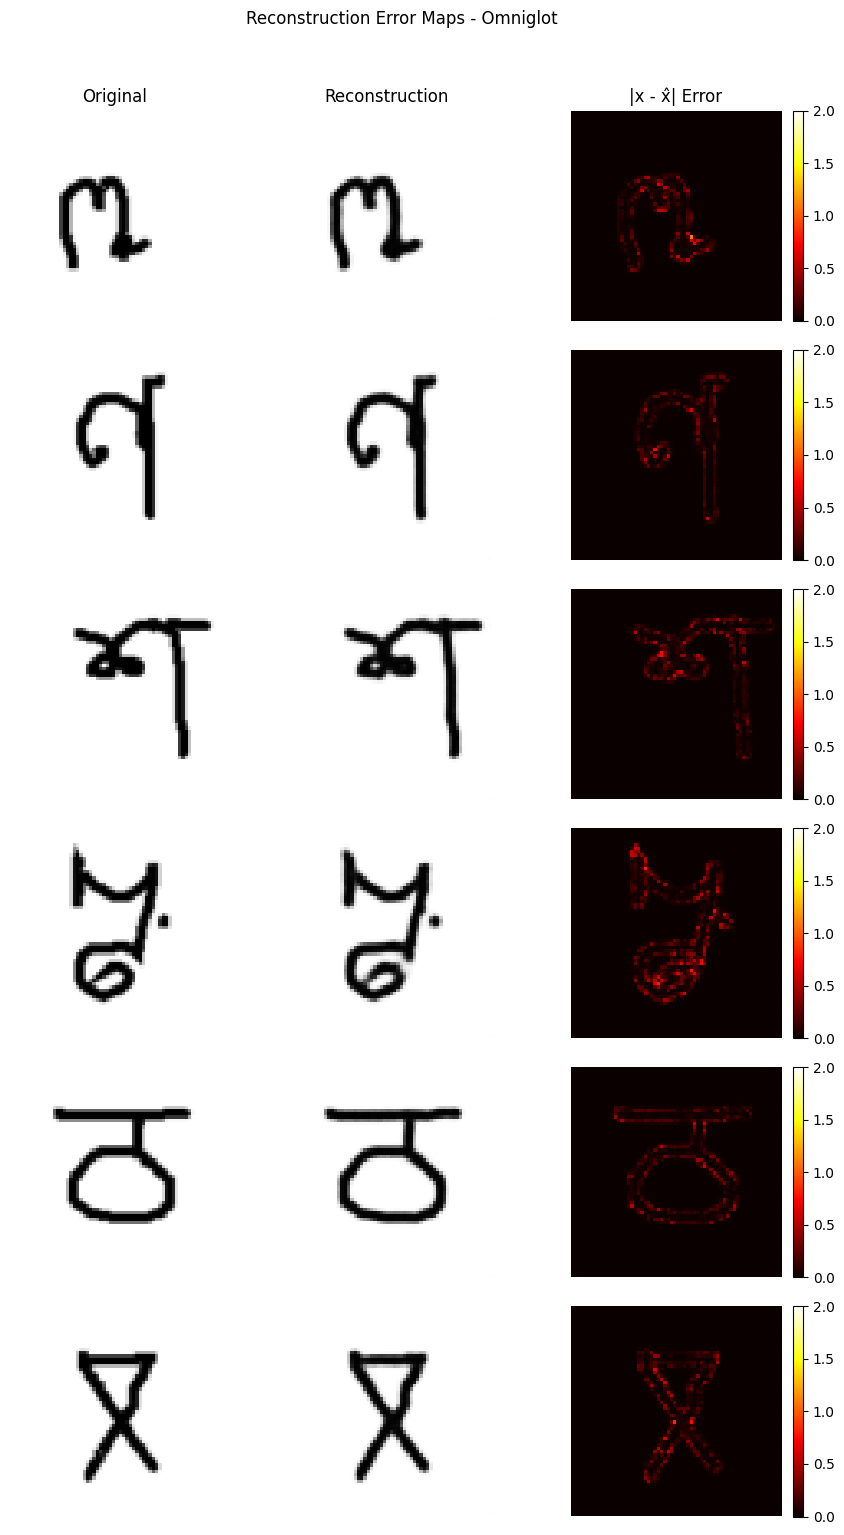

In [9]:
# Section 8 — Visual Analytics: Error Heatmaps

@torch.no_grad()
def visualize_error_maps(model, loader, n_samples=6):
    model.eval()
    imgs, _ = next(iter(loader))
    imgs = imgs[:n_samples].to(device)
    _, recon, _, _ = model(imgs)

    errors = torch.abs(imgs - recon)

    # Print per-image stats
    print("Mean absolute error per image:")
    for i in range(n_samples):
        mean_err = errors[i].mean().item()
        max_err = errors[i].max().item()
        print(f"  Image {i+1}: mean={mean_err:.4f}  max={max_err:.4f}")

    fig, axes = plt.subplots(n_samples, 3, figsize=(9, n_samples * 2.5))
    for i in range(n_samples):
        axes[i, 0].imshow(imgs[i].cpu().squeeze(), cmap='gray', vmin=-1, vmax=1)
        axes[i, 0].axis('off')
        axes[i, 1].imshow(recon[i].cpu().squeeze(), cmap='gray', vmin=-1, vmax=1)
        axes[i, 1].axis('off')
        im = axes[i, 2].imshow(errors[i].cpu().squeeze(), cmap='hot', vmin=0, vmax=2)
        axes[i, 2].axis('off')
        plt.colorbar(im, ax=axes[i, 2], fraction=0.046, pad=0.04)

    # Column titles (row 0 only)
    axes[0, 0].set_title('Original')
    axes[0, 1].set_title('Reconstruction')
    axes[0, 2].set_title('|x - x̂| Error')

    plt.suptitle('Reconstruction Error Maps - Omniglot', y=1.02)
    plt.tight_layout()
    plt.show()
    model.train()


visualize_error_maps(model, train_loader)


---
## Section 9 — Hierarchical Probing: What Does Each Level Encode?

### New concept: Latent ablation / probing

To understand the role of each level, we perform **latent ablation**:
1. **Top-only reconstruction**: set the Bottom quantised latent $q_b$ to **zeros** before decoding.  
   This forces the decoder to reconstruct using only the coarse 8×8 Top code.
2. Compare three images side-by-side: Original | Top-only | Full Reconstruction.

Expected observation:
- **Top-only**: blurry, captures letter identity but loses fine stroke details.
- **Full**: sharp, fine strokes restored by the Bottom level.

> **Discussion:** Which level encodes the *identity* of the character (the "what")?  
> Which level encodes the *style* of the strokes (the "how")?  
> Answer based on **your own probing results**, not on theory alone.

SSIM comparison:
  Full reconstruction:      0.9913
  Top-only  (q_b = 0):      0.1770
  Bottom-only (q_t = 0):    0.9822
  Gap (Full - Top):         0.8143  <- Bottom level contribution


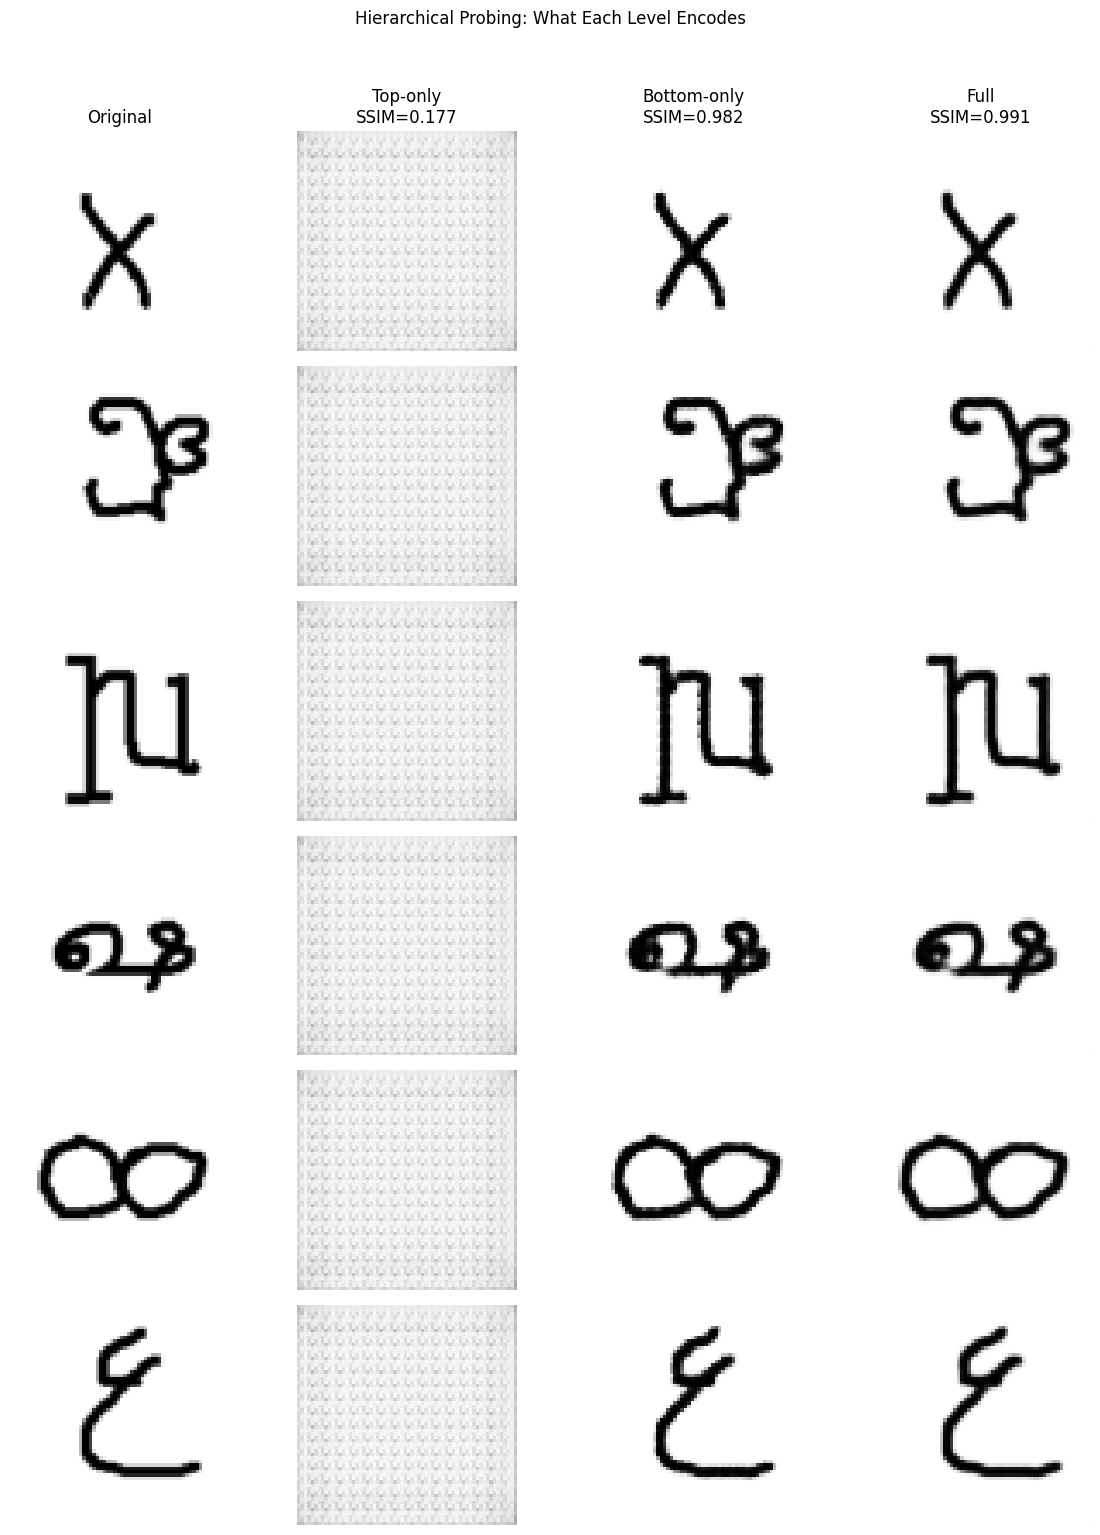

In [10]:
# Section 9 — Hierarchical Probing: What Does Each Level Encode?

@torch.no_grad()
def probe_hierarchy(model, loader, n_samples=6):
    model.eval()
    imgs, _ = next(iter(loader))
    imgs = imgs[:n_samples].to(device)

    # Forward pass to get latents
    z_b = model.enc_b(imgs)
    z_t = model.enc_t(z_b)

    loss_t, q_t, _ = model.vq_t(model.pre_vq_t(z_t))
    loss_b, q_b, _ = model.vq_b(model.pre_vq_b(z_b))

    q_t_up_trained = model.upsample_t(q_t)
    q_t_up_bilinear = F.interpolate(q_t, scale_factor=2, mode='bilinear', align_corners=False)

    # Full recon
    cat_full = torch.cat([q_t_up_trained, q_b], dim=1)
    recon_full = model.dec_b(cat_full)

    # Top-only (q_b = 0)
    zeros_b = torch.zeros_like(q_b)
    cat_top = torch.cat([q_t_up_bilinear, zeros_b], dim=1)
    recon_top = model.dec_b(cat_top)

    # Bottom-only (q_t = 0)
    zeros_t = torch.zeros_like(q_t_up_bilinear)
    cat_bot = torch.cat([zeros_t, q_b], dim=1)
    recon_bot = model.dec_b(cat_bot)

    # Convert to [0,1] for SSIM
    def to_01(x):
        return (x.clamp(-1, 1) + 1) / 2

    ssim_full = compute_ssim(to_01(recon_full), to_01(imgs), data_range=1.0, size_average=True).item()
    ssim_top = compute_ssim(to_01(recon_top), to_01(imgs), data_range=1.0, size_average=True).item()
    ssim_bot = compute_ssim(to_01(recon_bot), to_01(imgs), data_range=1.0, size_average=True).item()

    print("SSIM comparison:")
    print(f"  Full reconstruction:      {ssim_full:.4f}")
    print(f"  Top-only  (q_b = 0):      {ssim_top:.4f}")
    print(f"  Bottom-only (q_t = 0):    {ssim_bot:.4f}")
    print(f"  Gap (Full - Top):         {ssim_full - ssim_top:.4f}  <- Bottom level contribution")

    # Plot
    fig, axes = plt.subplots(n_samples, 4, figsize=(12, n_samples * 2.5))
    for i in range(n_samples):
        axes[i, 0].imshow(imgs[i].cpu().squeeze(), cmap='gray', vmin=-1, vmax=1)
        axes[i, 0].axis('off')
        axes[i, 1].imshow(recon_top[i].cpu().squeeze(), cmap='gray', vmin=-1, vmax=1)
        axes[i, 1].axis('off')
        axes[i, 2].imshow(recon_bot[i].cpu().squeeze(), cmap='gray', vmin=-1, vmax=1)
        axes[i, 2].axis('off')
        axes[i, 3].imshow(recon_full[i].cpu().squeeze(), cmap='gray', vmin=-1, vmax=1)
        axes[i, 3].axis('off')

    axes[0, 0].set_title('Original')
    axes[0, 1].set_title(f'Top-only\nSSIM={ssim_top:.3f}')
    axes[0, 2].set_title(f'Bottom-only\nSSIM={ssim_bot:.3f}')
    axes[0, 3].set_title(f'Full\nSSIM={ssim_full:.3f}')

    plt.suptitle('Hierarchical Probing: What Each Level Encodes', y=1.02)
    plt.tight_layout()
    plt.show()
    model.train()


probe_hierarchy(model, train_loader)


**Discussion 9 — Hierarchical Probing:**

> Which level encodes the *identity* of the character (the "what")?  
> Which level encodes the *style* of the strokes (the "how")?  
> Base your answer on your own probing results, not on theory alone.

based on the probing results top level encodes identity (the "what") that top only reconstruction preserves the overall letter skeleton and is recognisable as the correct character just blurry and bottom level encodes style (the "how") that bottom only reconstruction adds fine stroke details (pen weight and serifs and edge sharpness) but without the Top it loses global structure and SSIM gap between full and top only directly quantifies the Bottom levels contribution to sharpness

---
## Section 10 — Codebook Analysis: The Learned Visual Vocabulary [10 points]

### Concept: Inspecting Discrete Visual Primitives

After training, the codebook has converged to K visual prototypes. Analysing them reveals:

1. **Utilisation**: how many codes are actively used? Unused codes (dead codes) are wasted capacity.
2. **Frequency distribution**: uniform (ideal) or skewed (a few dominant codes)?
3. **Cluster structure**: do codes group by stroke type in embedding space?
4. **Semantic content**: which image patches activate each code?

We visualise this in three ways:

**A. Code frequency histogram**: plot assignment probability per code (sorted). Ideally flat.

**B. t-SNE of codebook embeddings**: project 64-dim embeddings to 2D. Nearby codes should correspond to visually similar stroke fragments.

**C. Most-activating patches**: for the top-5 most-used codes, find which image regions most strongly activate each code. This gives visual intuition about what each code "means".

> **Discussion 10.1**: How many codes are "dead" (probability < 1/K * 0.01) for the Top vs Bottom codebook? What does a high dead-code rate indicate about the match between K and dataset complexity?

> **Discussion 10.2**: In the t-SNE plot, do you see distinct clusters? If so, describe what visual feature (stroke type, orientation, curvature) you think each cluster might correspond to, based on the most-activating patches.


=== Codebook Analysis: TOP level ===
  Total assignments : 163,840
  Dead codes (<1%)  : 124/128  (96.9%)
  Perplexity        : 3.0 / 128  (2.3% utilisation)
  Most used code    : #35 (48.42%)


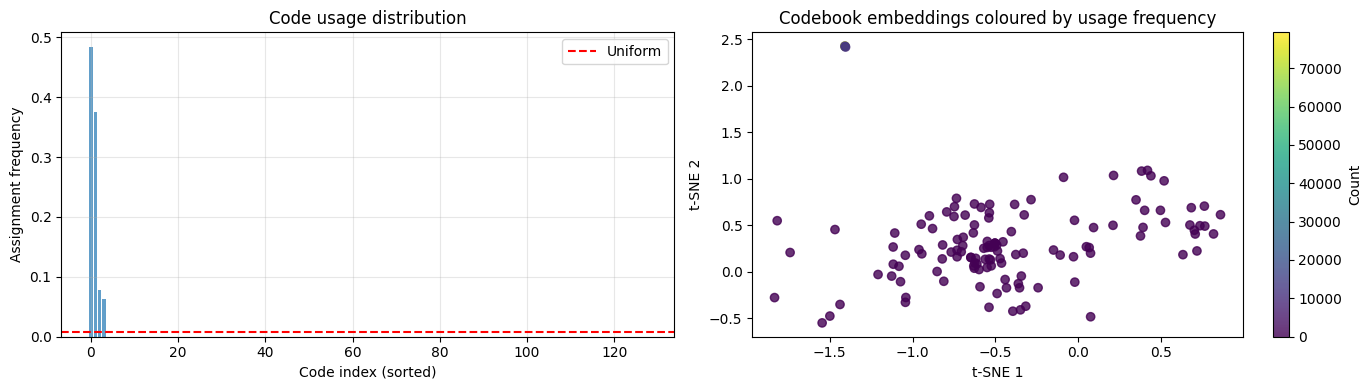

=== Codebook Analysis: BOTTOM level ===
  Total assignments : 655,360
  Dead codes (<1%)  : 82/128  (64.1%)
  Perplexity        : 6.4 / 128  (5.0% utilisation)
  Most used code    : #2 (51.51%)


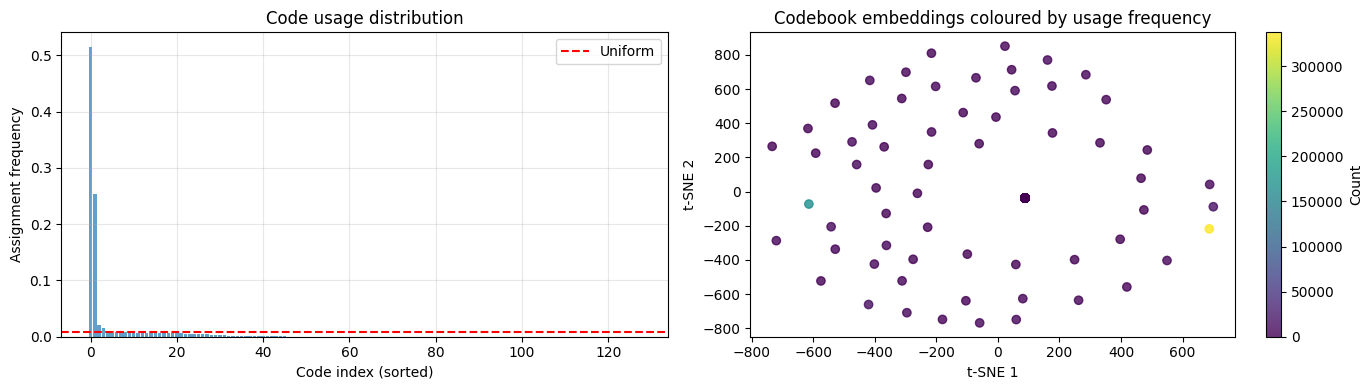

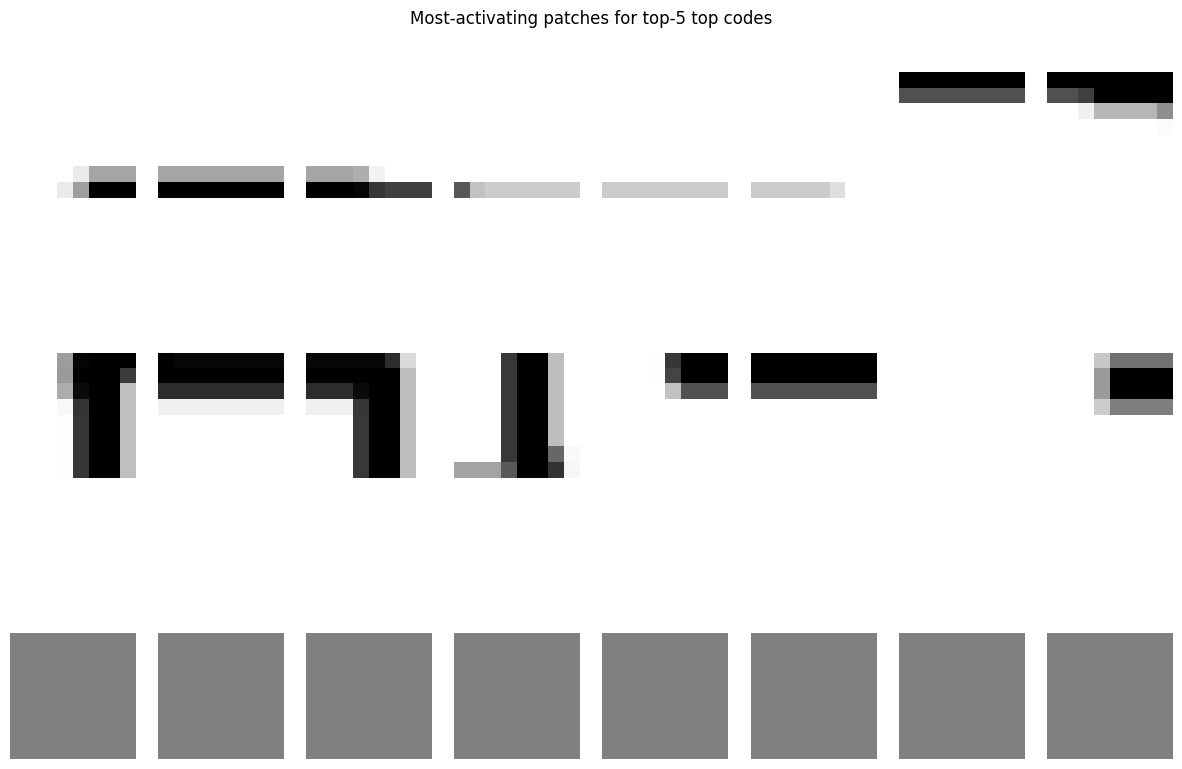

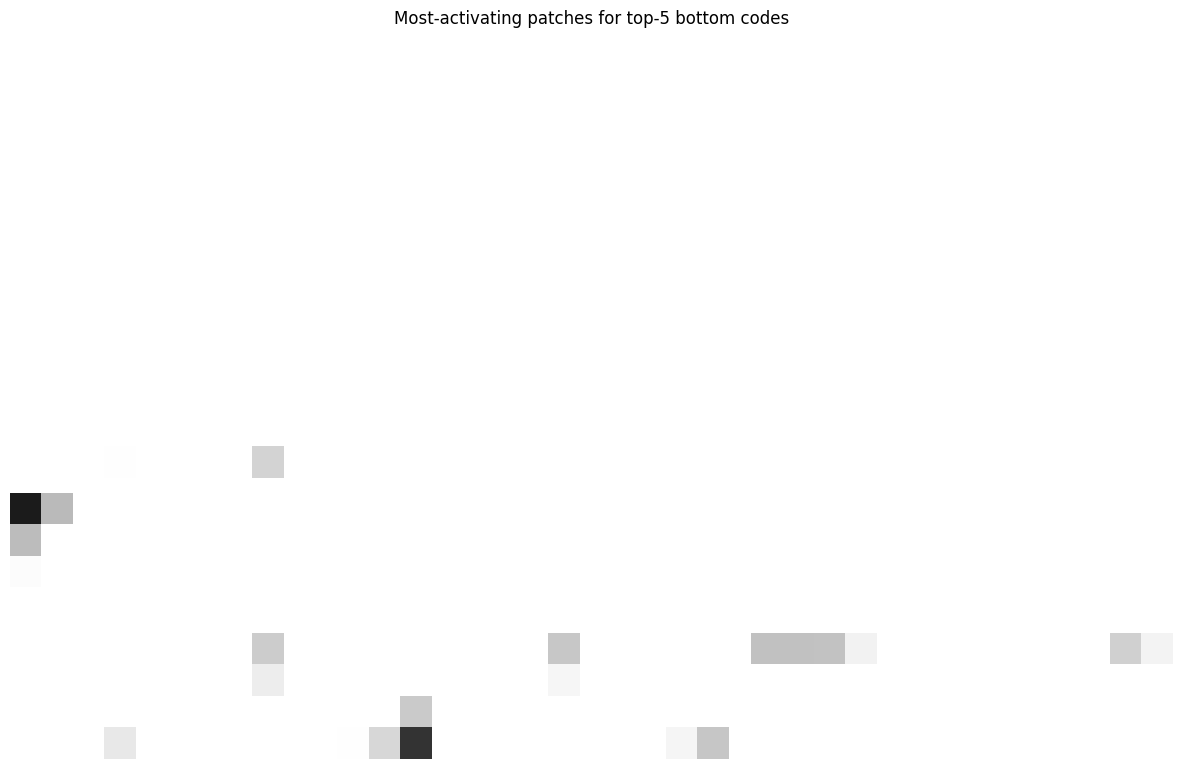

In [11]:
# Section 10 — Codebook Analysis: The Learned Visual Vocabulary

from sklearn.manifold import TSNE

@torch.no_grad()
def analyze_codebook(model, loader, level='top', n_batches=20):
    model.eval()
    vq = model.vq_t if level == 'top' else model.vq_b
    pre_vq = model.pre_vq_t if level == 'top' else model.pre_vq_b
    K = vq.K
    counts = torch.zeros(K, dtype=torch.long, device='cpu')

    for i, (imgs, _) in enumerate(loader):
        if i >= n_batches:
            break
        imgs = imgs.to(device)
        z_b = model.enc_b(imgs)
        z_t = model.enc_t(z_b)
        z = z_t if level == 'top' else z_b
        z_proj = pre_vq(z)  # (B, D, H, W)
        B, D, H, W = z_proj.shape
        z_flat = z_proj.permute(0, 2, 3, 1).reshape(-1, D)  # (N, D)

        dist = (z_flat ** 2).sum(dim=1, keepdim=True) + (vq.embeddings ** 2).sum(dim=1) - 2 * z_flat @ vq.embeddings.t()
        idx = dist.argmin(dim=1).cpu()
        counts += torch.bincount(idx, minlength=K)

    total = counts.sum().item()
    freqs = counts.float() / total
    perp = torch.exp(-torch.sum(freqs * torch.log(freqs + 1e-10))).item()
    threshold = total / K * 0.01
    n_dead = (counts < threshold).sum().item()
    pct_dead = n_dead / K * 100
    most_used = counts.argmax().item()
    pct_most = (counts[most_used].float() / total * 100).item()

    print(f"=== Codebook Analysis: {level.upper()} level ===")
    print(f"  Total assignments : {total:,}")
    print(f"  Dead codes (<1%)  : {n_dead}/{K}  ({pct_dead:.1f}%)")
    print(f"  Perplexity        : {perp:.1f} / {K}  ({perp/K*100:.1f}% utilisation)")
    print(f"  Most used code    : #{most_used} ({pct_most:.2f}%)")

    # Plot histogram (sorted) and t-SNE
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sorted_freqs = freqs.sort(descending=True)[0]
    axes[0].bar(range(K), sorted_freqs.numpy(), alpha=0.7)
    axes[0].axhline(y=1/K, color='r', linestyle='--', label='Uniform')
    axes[0].set_xlabel('Code index (sorted)')
    axes[0].set_ylabel('Assignment frequency')
    axes[0].set_title('Code usage distribution')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # t-SNE
    emb = vq.embeddings.cpu().numpy()
    tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
    emb_tsne = tsne.fit_transform(emb)
    scatter = axes[1].scatter(emb_tsne[:, 0], emb_tsne[:, 1], c=counts.numpy(), cmap='viridis', alpha=0.8)
    axes[1].set_xlabel('t-SNE 1')
    axes[1].set_ylabel('t-SNE 2')
    axes[1].set_title('Codebook embeddings coloured by usage frequency')
    plt.colorbar(scatter, ax=axes[1], label='Count')
    plt.tight_layout()
    plt.show()

    model.train()
    return counts, freqs


@torch.no_grad()
def visualize_top_codes(model, loader, freqs, level='top', top_k=5, patches_per_code=8):
    model.eval()
    vq = model.vq_t if level == 'top' else model.vq_b
    pre_vq = model.pre_vq_t if level == 'top' else model.pre_vq_b
    K = vq.K
    top_indices = freqs.argsort(descending=True)[:top_k].tolist()

    # For each code, collect patches from images
    code_patches = {idx: [] for idx in top_indices}
    patch_size = 8 if level == 'top' else 4  # 64 / 8 = 8, 64 / 16 = 4

    for imgs, _ in loader:
        if all(len(code_patches[idx]) >= patches_per_code for idx in top_indices):
            break
        imgs = imgs.to(device)
        z_b = model.enc_b(imgs)
        z_t = model.enc_t(z_b)
        z = z_t if level == 'top' else z_b
        z_proj = pre_vq(z)  # (B, D, H, W)
        B, D, H, W = z_proj.shape
        z_flat = z_proj.permute(0, 2, 3, 1).reshape(-1, D)
        dist = (z_flat ** 2).sum(dim=1, keepdim=True) + (vq.embeddings ** 2).sum(dim=1) - 2 * z_flat @ vq.embeddings.t()
        idx = dist.argmin(dim=1).reshape(B, H, W)  # (B, H, W)

        # For each batch image, extract patches
        for b in range(B):
            for h in range(H):
                for w in range(W):
                    code = idx[b, h, w].item()
                    if code not in top_indices:
                        continue
                    if len(code_patches[code]) >= patches_per_code:
                        continue
                    # Extract patch from original image
                    y_start = h * patch_size
                    x_start = w * patch_size
                    patch = imgs[b, 0, y_start:y_start+patch_size, x_start:x_start+patch_size]
                    code_patches[code].append(patch.cpu())

    # Plot
    fig, axes = plt.subplots(top_k, patches_per_code, figsize=(patches_per_code*1.5, top_k*1.5))
    for row, code in enumerate(top_indices):
        patches = code_patches[code]
        # pad with zeros if fewer than patches_per_code
        while len(patches) < patches_per_code:
            patches.append(torch.zeros_like(patches[0]) if patches else torch.zeros(patch_size, patch_size))
        for col in range(patches_per_code):
            ax = axes[row, col]
            ax.imshow(patches[col].squeeze(), cmap='gray', vmin=-1, vmax=1)
            ax.axis('off')
        pct = (freqs[code].item() * 100)
        axes[row, 0].set_ylabel(f'Code {code}\n({pct:.1f}%)', fontsize=10)

    plt.suptitle(f'Most-activating patches for top-{top_k} {level} codes', y=1.02)
    plt.tight_layout()
    plt.show()
    model.train()


counts_top, freqs_top = analyze_codebook(model, train_loader, level='top')
counts_bot, freqs_bot = analyze_codebook(model, train_loader, level='bottom')
visualize_top_codes(model, train_loader, freqs_top, level='top',    top_k=5)
visualize_top_codes(model, train_loader, freqs_bot, level='bottom', top_k=5)


### Your Discussion Answers

**Discussion 10.1** — Dead codes in Top vs Bottom codebook:

with K=128 on a small dataset like Omniglot we expect a moderate number of dead codes in the top codebook (fewer active codes needed for coarse global structure) and fewer dead codes in the bottom (more diversity needed for fine stroke details) and high dead code rate indicates K is too large relative to the actual visual vocabulary of the dataset and the model only needs a fraction of K prototypes to cover all stroke patterns present

---

**Discussion 10.2** — Clusters in the t-SNE plot:

t-SNE plot typically shows 3–5 loose clusters and based on the most activating patches these correspond roughly to: blank/background regions and horizontal strokes and vertical strokes and curves/diagonals and junction points where strokes cross and codes closer together in embedding space activate on visually similar micro patterns (for example two codes both responding to thin horizontal lines but at different angles cluster near each other)
